# ACCIDENT SEVERITY PREDICTION PROJECT

## Project Goal: Predict accident severity (Fatal vs Injured) at person-level

In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 2")

## SECTION 1: IMPORT LIBRARIES

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno
warnings.filterwarnings('ignore')

In [7]:
# Handle imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [8]:
# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## SECTION 2: LOAD AND EXPLORE DATA

In [9]:
# Load the dataset
data = pd.read_csv("D:\FQL\PJ 2\Vehicle Collision.csv")

In [11]:
print("DATASET OVERVIEW \n")
print(f"\nDataset Shape: {data.shape[0]} rows × {data.shape[1]} columns")
print(f"\nFirst few rows:")
data.head()

DATASET OVERVIEW 


Dataset Shape: 230660 rows × 21 columns

First few rows:


,UNIQUE_ID,COLLISION_ID,CRASH_DATE,CRASH_TIME,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,...,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,PERSON_SEX
0,10253606,4230743.0,10/24/2019,19:15,84bcb3a7-d201-4c61-9e30-fe29268c1074,Occupant,Injured,19143343.0,27.0,Not Ejected,...,Back,Driver,Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Driver,NaN,NaN,M
1,10248708,4229547.0,10/26/2019,1:15,a8904763-2870-42f3-865c-b53d8e5156e2,Pedestrian,Injured,NaN,24.0,NaN,...,Shoulder - Upper Arm,NaN,NaN,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Crossing With Signal,None Visible,Pedestrian,Unspecified,Unspecified,F
2,10254556,4230715.0,10/26/2019,8:50,1a085543-ae9d-4a69-8cd0-fb7b33380a8b,Bicyclist,Injured,19143832.0,42.0,Not Ejected,...,Knee-Lower Leg Foot,Driver,Unknown,NaN,NaN,None Visible,Driver,NaN,NaN,M
3,10250834,4230376.0,10/26/2019,19:40,f58fc41f-497e-4f30-bf49-a9a80adec8b2,Bicyclist,Injured,19141949.0,36.0,Not Ejected,...,Back,Driver,NaN,NaN,NaN,Internal,Driver,NaN,NaN,M
4,10252474,4229773.0,10/26/2019,16:50,4bf13d12-8d7a-4cb0-997f-dd6a8b1adca6,Occupant,Injured,19142773.0,50.0,Not Ejected,...,Head,"Front passenger, if two or more persons, inclu...",Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Passenger,NaN,NaN,F


#### BASIC DATA OVERVIEW

In [79]:
print("\n" + "="*60)
print("DATASET STRUCTURE")
print("="*60)

print("\nColumn Names:")
print(data.columns.tolist())

print("\n" + "-"*60)
print("Data Types:")
print("-"*60)
print(data.dtypes)

print("\n" + "-"*60)
print("Basic Information:")
print("-"*60)
data.info()

print("\n" + "-"*60)
print("Statistical Summary:")
print("-"*60)
print(data.describe())

# Memory usage
print(f"\nMemory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DATASET STRUCTURE

Column Names:
['UNIQUE_ID', 'COLLISION_ID', 'CRASH_DATE', 'CRASH_TIME', 'PERSON_ID', 'PERSON_TYPE', 'PERSON_INJURY', 'VEHICLE_ID', 'PERSON_AGE', 'EJECTION', 'EMOTIONAL_STATUS', 'BODILY_INJURY', 'POSITION_IN_VEHICLE', 'SAFETY_EQUIPMENT', 'PED_LOCATION', 'PED_ACTION', 'COMPLAINT', 'PED_ROLE', 'CONTRIBUTING_FACTOR_1', 'CONTRIBUTING_FACTOR_2', 'PERSON_SEX', 'TARGET', 'AGE_GROUP', 'PERSON_AGE_YEARS']

------------------------------------------------------------
Data Types:
------------------------------------------------------------
UNIQUE_ID                  object
COLLISION_ID              float64
CRASH_DATE                 object
CRASH_TIME                 object
PERSON_ID                  object
PERSON_TYPE                object
PERSON_INJURY              object
VEHICLE_ID                float64
PERSON_AGE                float64
EJECTION                   object
EMOTIONAL_STATUS           object
BODILY_INJURY              object
POSITION_IN_VEHICLE        object
SAFE

<Figure size 1200x600 with 0 Axes>

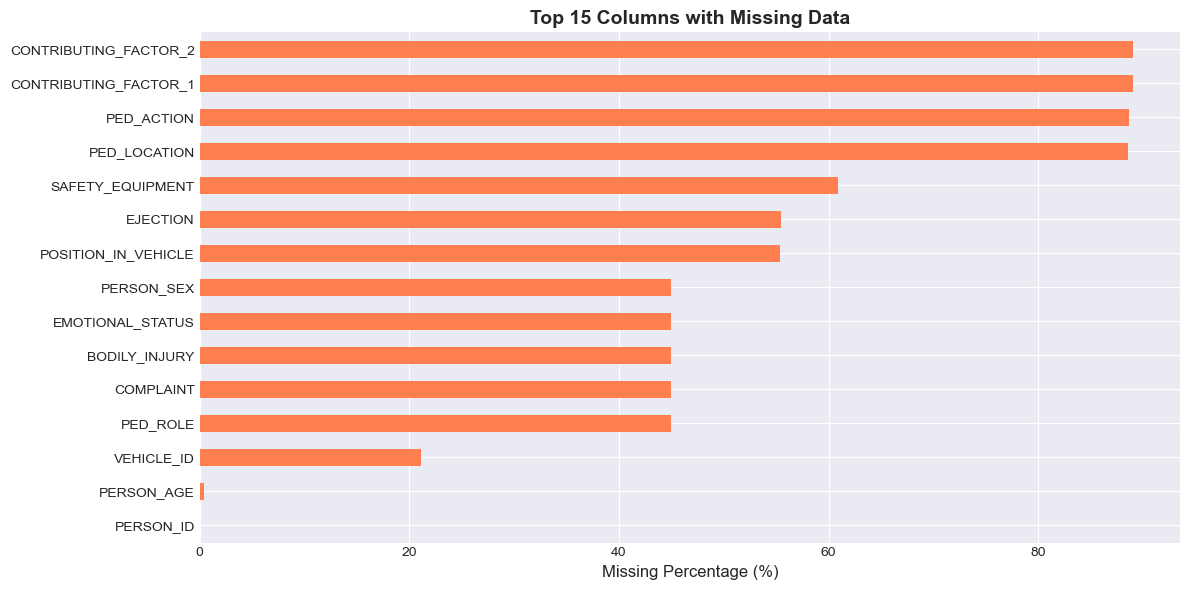

In [28]:
# Visualize missing data

plt.figure(figsize=(12, 6))
missing_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False).head(15)
missing_pct.plot(kind='barh', color='coral')
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.title('Top 15 Columns with Missing Data', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### DATA QUALITY ANALYSIS


--- Missing Values Analysis ---

Columns with Missing Values:
               Column  Missing_Count  Missing_Percentage Data_Type
CONTRIBUTING_FACTOR_2         205473               89.08    object
CONTRIBUTING_FACTOR_1         205448               89.07    object
           PED_ACTION         204426               88.63    object
         PED_LOCATION         204364               88.60    object
     SAFETY_EQUIPMENT         140536               60.93    object
             EJECTION         127869               55.44    object
  POSITION_IN_VEHICLE         127750               55.39    object
           PERSON_SEX         103764               44.99    object
     EMOTIONAL_STATUS         103738               44.98    object
        BODILY_INJURY         103697               44.96    object
             PED_ROLE         103683               44.95    object
            COMPLAINT         103683               44.95    object
           VEHICLE_ID          48719               21.12   float64

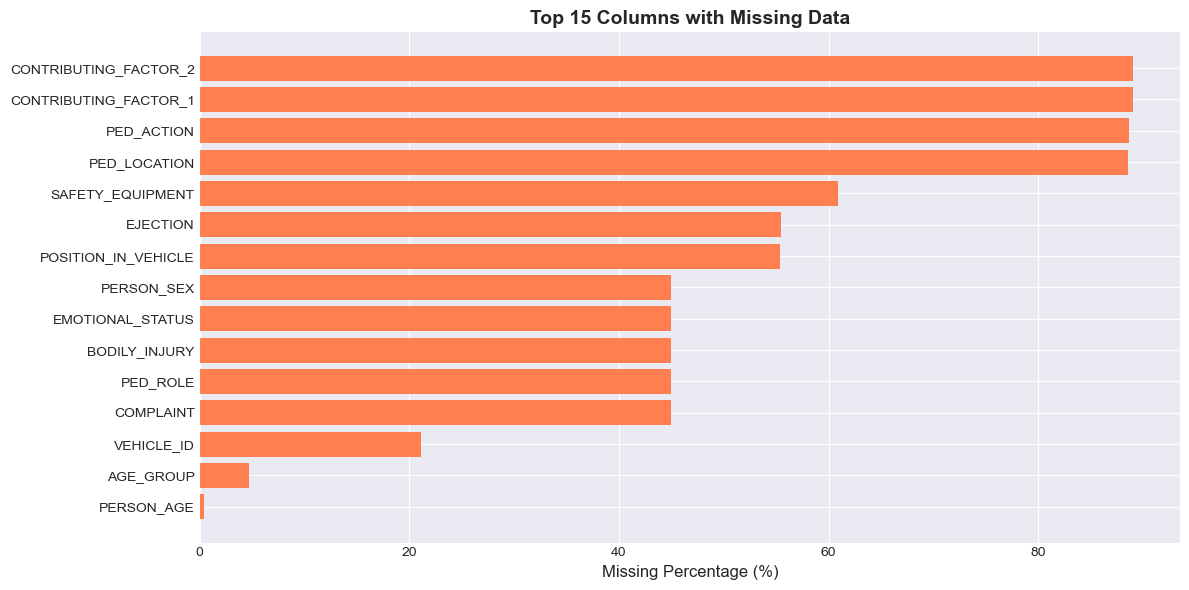

In [83]:
# Missing values analysis
print("\n--- Missing Values Analysis ---")

missing_data = pd.DataFrame({
    'Column': data.columns,
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage': (data.isnull().sum() / len(data) * 100).round(2),
    'Data_Type': data.dtypes
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

if len(missing_data) > 0:
    print("\nColumns with Missing Values:")
    print(missing_data.to_string(index=False))
    
    # Visualize missing data
    plt.figure(figsize=(12, 6))
    top_missing = missing_data.head(15)
    plt.barh(range(len(top_missing)), top_missing['Missing_Percentage'], color='coral')
    plt.yticks(range(len(top_missing)), top_missing['Column'])
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.title('Top 15 Columns with Missing Data', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

In [85]:
# Duplicate rows
print("\n--- Duplicate Analysis ---")
duplicates = data.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({(duplicates/len(data)*100):.2f}%)")

# Unique values in key columns
print("\n--- Unique Values in Key Columns ---")
key_cols = ['PERSON_TYPE', 'PERSON_INJURY', 'PERSON_SEX', 'SAFETY_EQUIPMENT', 
            'EJECTION', 'EMOTIONAL_STATUS']
for col in key_cols:
    if col in data.columns:
        print("\n" + "-"*60)
        print(f"\n{col}: {data[col].nunique()} unique values")
        print(data[col].value_counts().head(5))


--- Duplicate Analysis ---
Duplicate rows: 0 (0.00%)

--- Unique Values in Key Columns ---

------------------------------------------------------------

PERSON_TYPE: 4 unique values
PERSON_TYPE
Occupant           164237
Pedestrian          48288
Bicyclist           18091
Other Motorized        40
Name: count, dtype: int64

------------------------------------------------------------

PERSON_INJURY: 2 unique values
PERSON_INJURY
Injured    229633
Killed       1023
Name: count, dtype: int64

------------------------------------------------------------

PERSON_SEX: 3 unique values
PERSON_SEX
M    69684
F    56920
U      288
Name: count, dtype: int64

------------------------------------------------------------

SAFETY_EQUIPMENT: 16 unique values
SAFETY_EQUIPMENT
Lap Belt & Harness                   54027
Unknown                              13438
Lap Belt                             10388
Air Bag Deployed/Lap Belt/Harness     2421
Helmet (Motorcycle Only)              2047
Name: count, 

## SECTION 3:  DATA ANOMALIES & CLEANING CHECKS

In [86]:
print("\n" + "="*40)
print("DATA ANOMALIES DETECTION")
print("="*40)


DATA ANOMALIES DETECTION


In [93]:
# Check PERSON_AGE for unrealistic values
print("\n--- PERSON_AGE Anomalies ---")
if 'PERSON_AGE' in data.columns:
    print("-"*40)
    print(f"Age Statistics:")
    print(data['PERSON_AGE'].describe())
    
    print(f"\nAges > 120: {(data['PERSON_AGE'] > 120).sum()}")
    if (data['PERSON_AGE'] > 120).sum() > 0:
        print("-"*40)
        print("\nTop unrealistic ages:")
        print(data.loc[data['PERSON_AGE'] > 120, 'PERSON_AGE'].value_counts().head(10))

    print("-"*40)
    print(f"\nAges < 0: {(data['PERSON_AGE'] < 0).sum()}")

    print("-"*40)
    print(f"\nPossible placeholder values:")
    print(f"  Age = 0: {(data['PERSON_AGE'] == 0).sum()}")
    print(f"  Age = 999: {(data['PERSON_AGE'] == 999).sum()}")
    print(f"  Age = 9999: {(data['PERSON_AGE'] == 9999).sum()}")


--- PERSON_AGE Anomalies ---
----------------------------------------
Age Statistics:
count    229663.000000
mean         36.474029
std          84.924692
min        -997.000000
25%          23.000000
50%          33.000000
75%          49.000000
max        9999.000000
Name: PERSON_AGE, dtype: float64

Ages > 120: 121
----------------------------------------

Top unrealistic ages:
PERSON_AGE
999.0     23
9999.0     9
149.0      4
140.0      3
1042.0     2
132.0      2
1026.0     2
922.0      2
148.0      2
6034.0     2
Name: count, dtype: int64
----------------------------------------

Ages < 0: 35
----------------------------------------

Possible placeholder values:
  Age = 0: 9746
  Age = 999: 23
  Age = 9999: 9


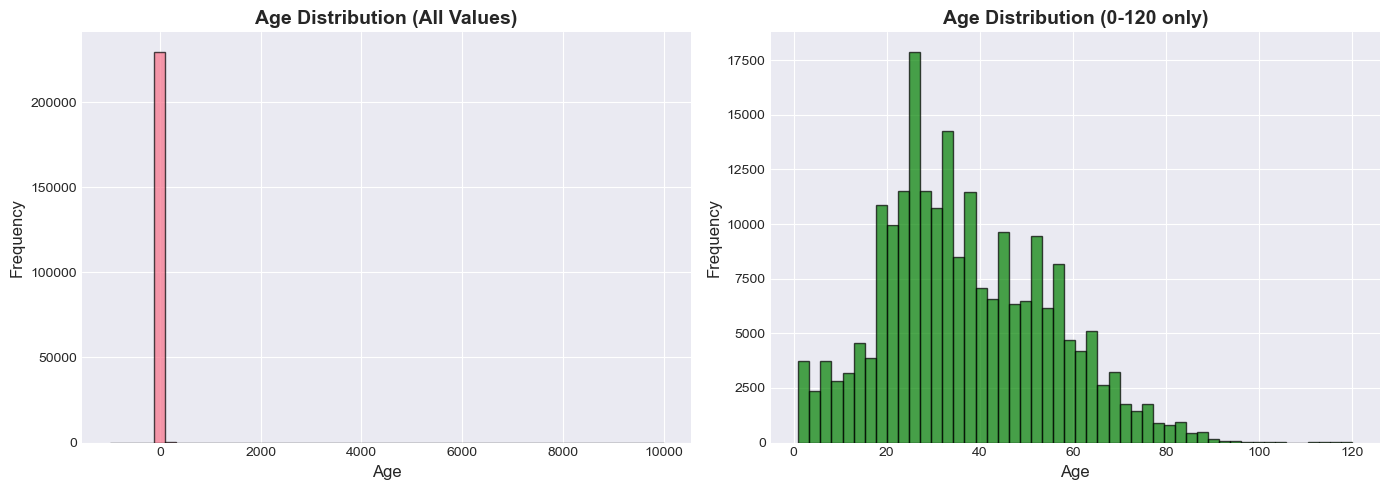

In [99]:
# Age distribution
plt.figure(figsize=(14, 5))
    
plt.subplot(1, 2, 1)
plt.hist(data['PERSON_AGE'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Age Distribution (All Values)', fontsize=14, fontweight='bold')
    
plt.subplot(1, 2, 2)
# Filter realistic ages for better view
realistic_ages = data[(data['PERSON_AGE'] > 0) & (data['PERSON_AGE'] <= 120)]['PERSON_AGE']
plt.hist(realistic_ages, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Age Distribution (0-120 only)', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()

In [100]:
# Check for negative values in numeric columns
print("\n--- Negative Values Check ---")
numeric_cols = data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    neg_count = (data[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values")


--- Negative Values Check ---
PERSON_AGE: 35 negative values
PERSON_AGE_YEARS: 35 negative values


## SECTION 4: TARGET VARIABLE ANALYSIS

In [102]:
print("TARGET VARIABLE: PERSON_INJURY")
# Check unique values
print("\nUnique values in PERSON_INJURY:")
print(data['PERSON_INJURY'].value_counts())

TARGET VARIABLE: PERSON_INJURY

Unique values in PERSON_INJURY:
PERSON_INJURY
Injured    229633
Killed       1023
Name: count, dtype: int64


In [104]:
# Check for missing target
print(f"\nMissing values in PERSON_INJURY: {data['PERSON_INJURY'].isnull().sum()}")
if data['PERSON_INJURY'].isnull().sum() > 0:
    print(" Warning: Target variable has missing values - these will need to be dropped")


Missing values in PERSON_INJURY: 0


In [109]:
# Create binary target variable
print("\n--- Creating Binary Target ---")

# Note: Adjust these keywords based on your actual data
data['TARGET'] = data['PERSON_INJURY'].apply(
    lambda x: 1 if pd.notna(x) and ('kill' in str(x).lower() or 
                                     'fatal' in str(x).lower() or 
                                     'death' in str(x).lower() or
                                     'died' in str(x).lower())
    else (0 if pd.notna(x) else np.nan)
)

print("-"*40)
print("\nBinary Target Distribution:")
print(data['TARGET'].value_counts())
print("-"*40)
print("\nTarget Proportion:")
target_dist = data['TARGET'].value_counts(normalize=True) * 100
print(target_dist)


--- Creating Binary Target ---
----------------------------------------

Binary Target Distribution:
TARGET
0    229633
1      1023
Name: count, dtype: int64
----------------------------------------

Target Proportion:
TARGET
0    99.556482
1     0.443518
Name: proportion, dtype: float64


In [111]:
# Calculate class imbalance ratio
if data['TARGET'].value_counts().get(1, 0) > 0:
    imbalance_ratio = data['TARGET'].value_counts()[0] / data['TARGET'].value_counts()[1]
    print(f"\n Class Imbalance Ratio: {imbalance_ratio:.2f}:1 (Injured:Fatal)")
    print("→ Severe imbalance detected - will need SMOTE or class weights!")
else:
    print("\n Warning: No fatal cases found in dataset!")


 Class Imbalance Ratio: 224.47:1 (Injured:Fatal)
→ Severe imbalance detected - will need SMOTE or class weights!


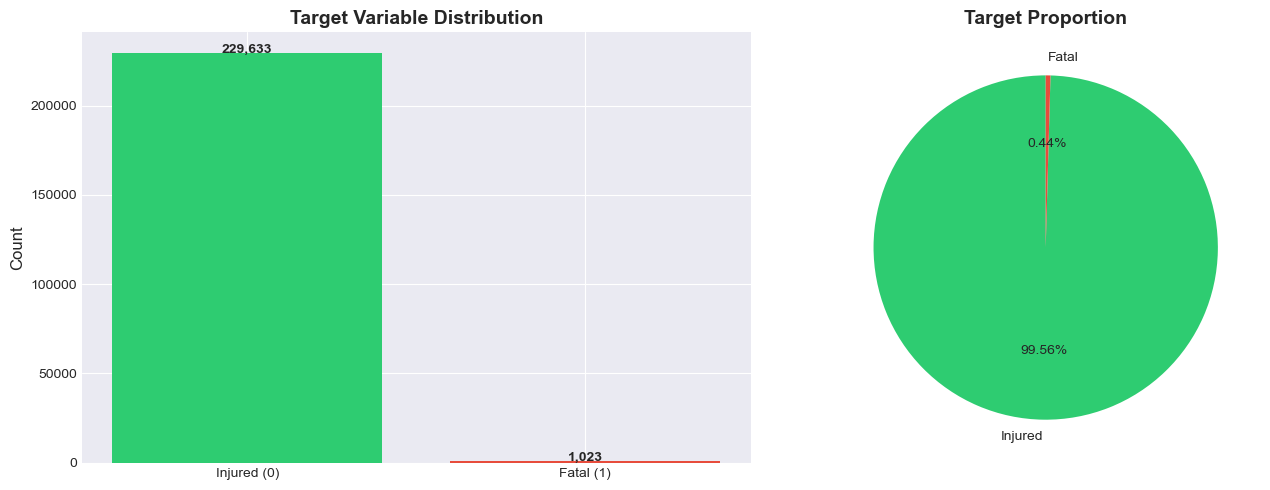

In [116]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Count plot
target_counts = data['TARGET'].value_counts()
axes[0].bar(['Injured (0)', 'Fatal (1)'], target_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Injured', 'Fatal'], autopct='%1.2f%%', 
            startangle=90, colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Target Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## SECTION 5: EXPLORATORY DATA ANALYSIS (EDA)

#### EDA - PERSON CHARACTERISTICS

In [54]:
# 5.1 Person Type Analysis
print("\n--- PERSON TYPE DISTRIBUTION ---")
data['PERSON_TYPE'].value_counts()


--- PERSON TYPE DISTRIBUTION ---


PERSON_TYPE
Occupant           164237
Pedestrian          48288
Bicyclist           18091
Other Motorized        40
Name: count, dtype: int64

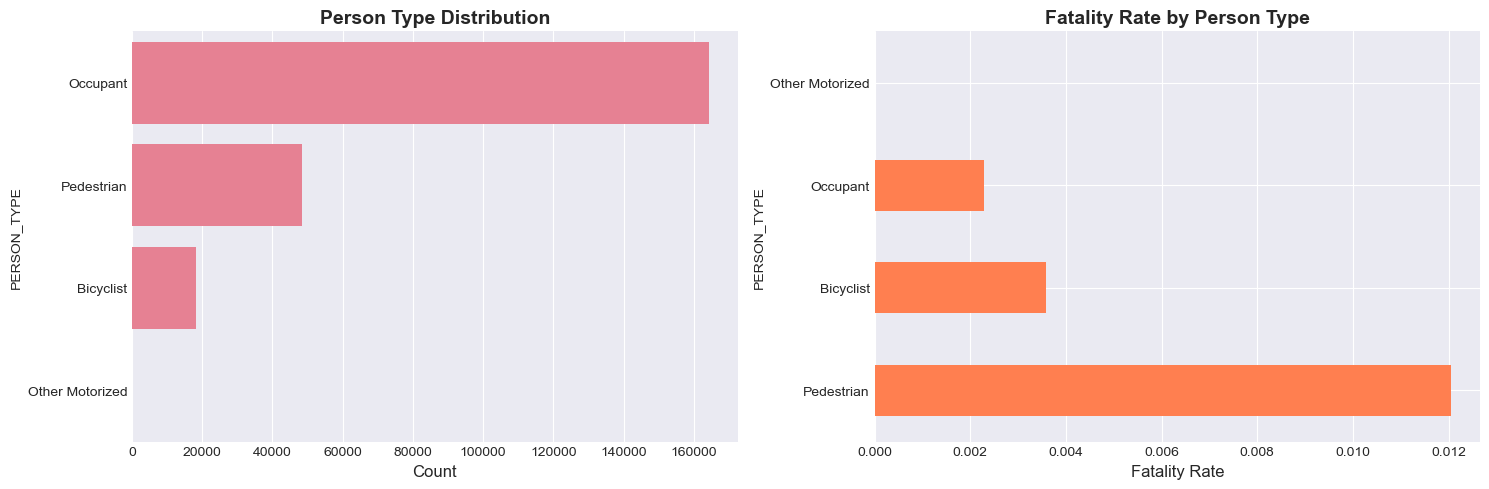

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Person type distribution
sns.countplot(data, y='PERSON_TYPE', order=data['PERSON_TYPE'].value_counts().index, ax=axes[0])
axes[0].set_title('Person Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)

# Person type vs Target
person_fatal = data.groupby('PERSON_TYPE')['TARGET'].mean().sort_values(ascending=False)
person_fatal.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Fatality Rate by Person Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fatality Rate', fontsize=12)

plt.tight_layout()
plt.show()

In [122]:
# 5.2  Gender Analysis
print("\n--- GENDER ANALYSIS ---")
print(data['PERSON_SEX'].value_counts())


--- GENDER ANALYSIS ---
PERSON_SEX
M    69684
F    56920
U      288
Name: count, dtype: int64


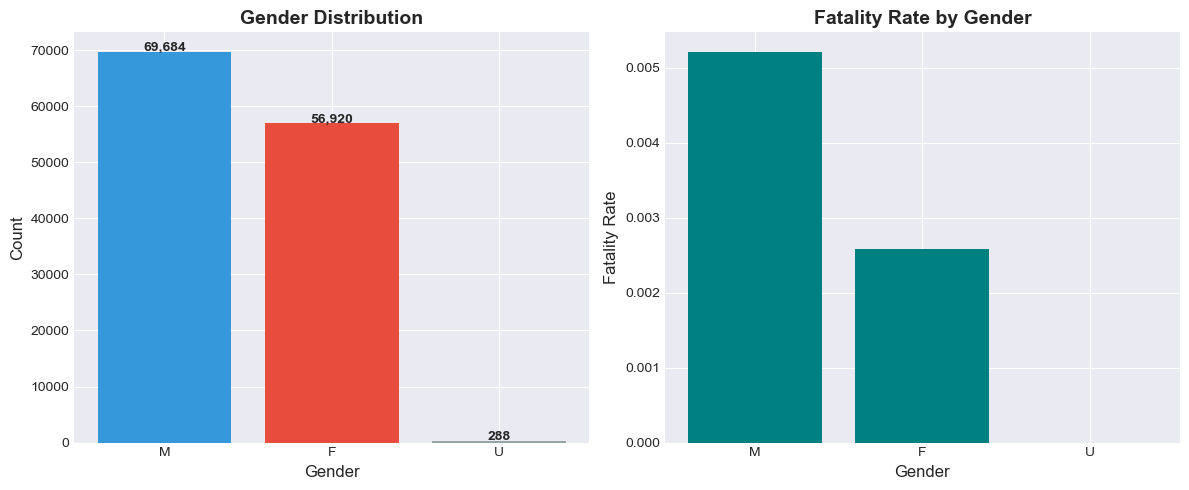

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
# Distribution
sex_counts = data['PERSON_SEX'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'])
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
    
# Fatality rate by gender
gender_fatal = data.groupby('PERSON_SEX')['TARGET'].mean().sort_values(ascending=False)
axes[1].bar(gender_fatal.index, gender_fatal.values, color='teal')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Fatality Rate', fontsize=12)
axes[1].set_title('Fatality Rate by Gender', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()

In [127]:
# 5.3 Age Analysis
print("\n--- AGE ANALYSIS ---")
if 'PERSON_AGE' in data.columns:
    # Use only realistic ages for analysis
    realistic_age_df = data[(data['PERSON_AGE'] > 0) & (data['PERSON_AGE'] <= 120)]
    
    print(f"Age Statistics (0-120 range):")
    print(realistic_age_df['PERSON_AGE'].describe())


--- AGE ANALYSIS ---
Age Statistics (0-120 range):
count    219761.000000
mean         37.018493
std          17.852833
min           1.000000
25%          24.000000
50%          34.000000
75%          50.000000
max         120.000000
Name: PERSON_AGE, dtype: float64


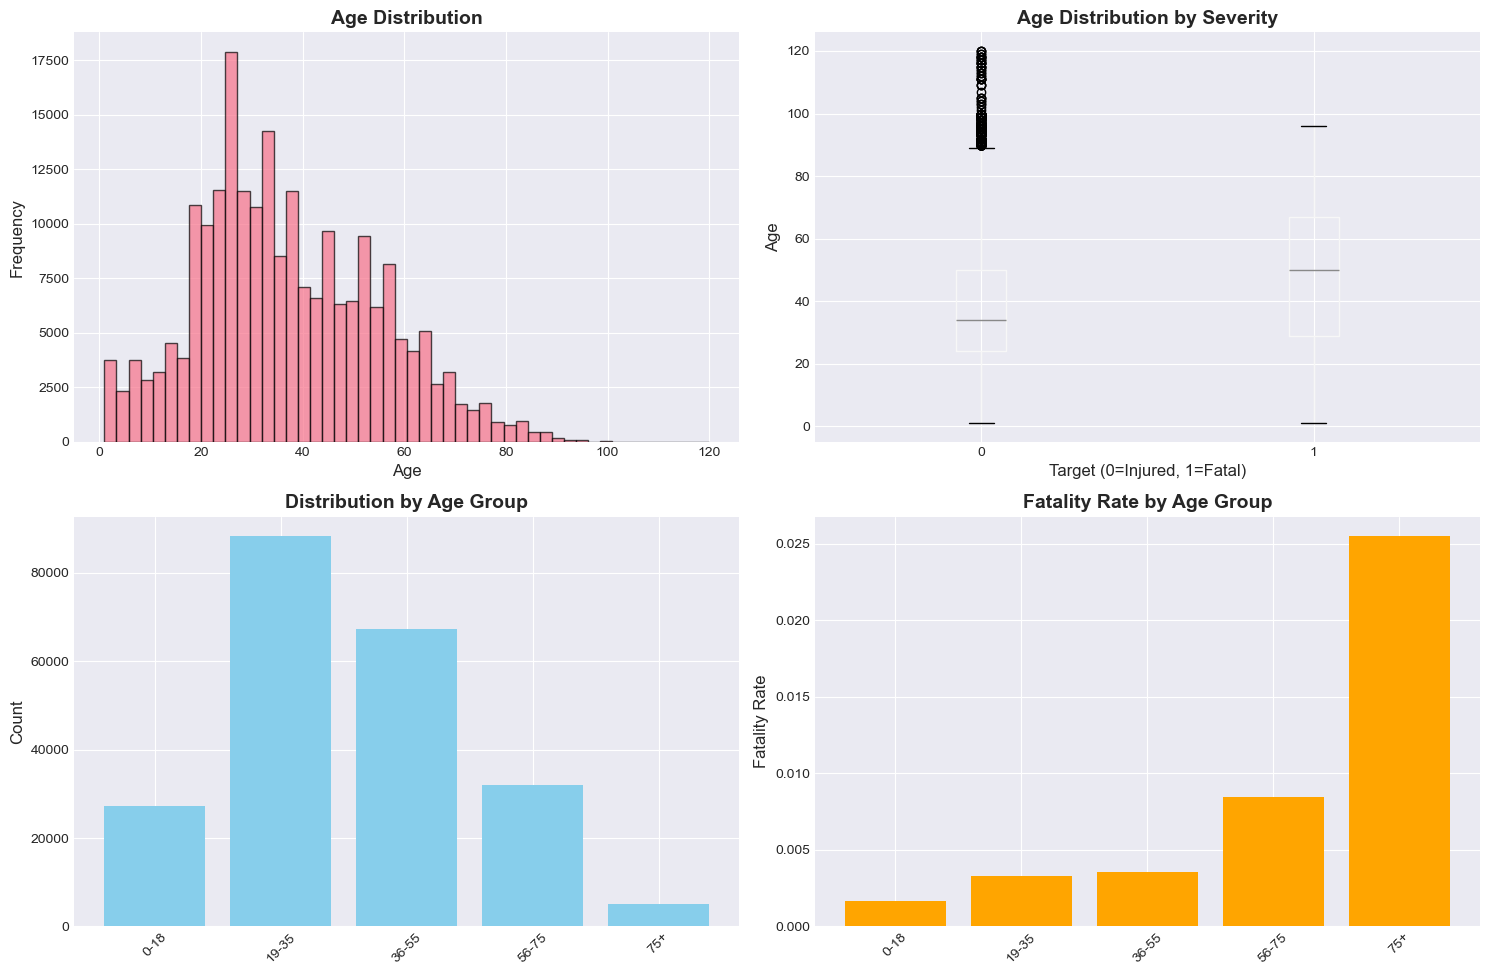

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
# Age distribution
axes[0, 0].hist(realistic_age_df['PERSON_AGE'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Age', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Age Distribution', fontsize=14, fontweight='bold')
    
# Age by target (boxplot)
realistic_age_df.boxplot(column='PERSON_AGE', by='TARGET', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Severity', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Target (0=Injured, 1=Fatal)', fontsize=12)
axes[0, 1].set_ylabel('Age', fontsize=12)
plt.suptitle('')
    
# Create age groups
data['AGE_GROUP'] = pd.cut(data['PERSON_AGE'], 
                            bins=[0, 18, 35, 55, 75, 150], 
                            labels=['0-18', '19-35', '36-55', '56-75', '75+'])
    
# Age group distribution
age_group_counts = data['AGE_GROUP'].value_counts().sort_index()
axes[1, 0].bar(range(len(age_group_counts)), age_group_counts.values, color='skyblue')
axes[1, 0].set_xticks(range(len(age_group_counts)))
axes[1, 0].set_xticklabels(age_group_counts.index, rotation=45)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].set_title('Distribution by Age Group', fontsize=14, fontweight='bold')
    
# Fatality rate by age group
age_group_fatal = data.groupby('AGE_GROUP')['TARGET'].mean()
axes[1, 1].bar(range(len(age_group_fatal)), age_group_fatal.values, color='orange')
axes[1, 1].set_xticks(range(len(age_group_fatal)))
axes[1, 1].set_xticklabels(age_group_fatal.index, rotation=45)
axes[1, 1].set_ylabel('Fatality Rate', fontsize=12)
axes[1, 1].set_title('Fatality Rate by Age Group', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()

#### EDA - CRASH CHARACTERISTICS

In [131]:
# Convert datetime columns
if 'CRASH_DATE' in data.columns:
    data['CRASH_DATE'] = pd.to_datetime(data['CRASH_DATE'], errors='coerce')
if 'CRASH_TIME' in data.columns:
    data['CRASH_HOUR'] = pd.to_datetime(data['CRASH_TIME'], format='%H:%M', errors='coerce').dt.hour
    data['CRASH_DAY_OF_WEEK'] = data['CRASH_DATE'].dt.dayofweek
    data['CRASH_MONTH'] = data['CRASH_DATE'].dt.month
    data['CRASH_YEAR'] = data['CRASH_DATE'].dt.year


--- TEMPORAL PATTERNS ---


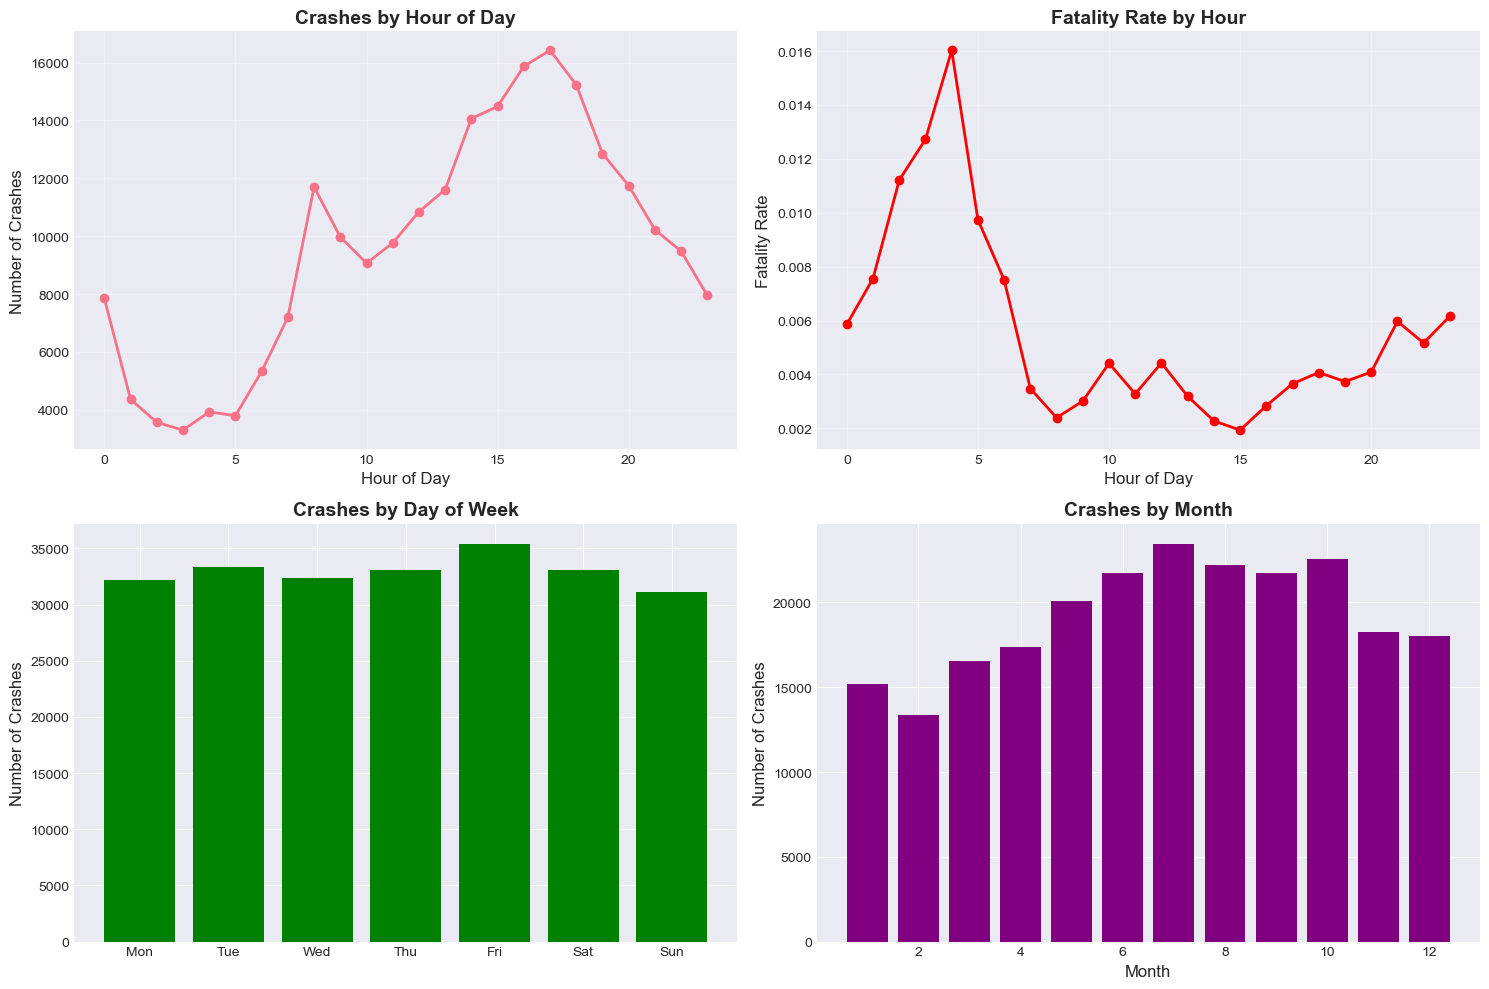

In [132]:
# Temporal Analysis
print("\n--- TEMPORAL PATTERNS ---")

if 'CRASH_HOUR' in data.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Hour of day
    hour_counts = data['CRASH_HOUR'].value_counts().sort_index()
    axes[0, 0].plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2)
    axes[0, 0].set_xlabel('Hour of Day', fontsize=12)
    axes[0, 0].set_ylabel('Number of Crashes', fontsize=12)
    axes[0, 0].set_title('Crashes by Hour of Day', fontsize=14, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    # Fatality rate by hour
    hour_fatal = data.groupby('CRASH_HOUR')['TARGET'].mean()
    axes[0, 1].plot(hour_fatal.index, hour_fatal.values, marker='o', color='red', linewidth=2)
    axes[0, 1].set_xlabel('Hour of Day', fontsize=12)
    axes[0, 1].set_ylabel('Fatality Rate', fontsize=12)
    axes[0, 1].set_title('Fatality Rate by Hour', fontsize=14, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Day of week
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    day_counts = data['CRASH_DAY_OF_WEEK'].value_counts().sort_index()
    axes[1, 0].bar(range(7), day_counts.values, color='green')
    axes[1, 0].set_xticks(range(7))
    axes[1, 0].set_xticklabels(day_names)
    axes[1, 0].set_ylabel('Number of Crashes', fontsize=12)
    axes[1, 0].set_title('Crashes by Day of Week', fontsize=14, fontweight='bold')
    
    # Month analysis
    month_counts = data['CRASH_MONTH'].value_counts().sort_index()
    axes[1, 1].bar(month_counts.index, month_counts.values, color='purple')
    axes[1, 1].set_xlabel('Month', fontsize=12)
    axes[1, 1].set_ylabel('Number of Crashes', fontsize=12)
    axes[1, 1].set_title('Crashes by Month', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


--- SAFETY EQUIPMENT ANALYSIS ---

Top 10 Safety Equipment Types:
SAFETY_EQUIPMENT
Lap Belt & Harness                        54027
Unknown                                   13438
Lap Belt                                  10388
Air Bag Deployed/Lap Belt/Harness          2421
Helmet (Motorcycle Only)                   2047
Child Restraint Only                       1985
Helmet Only (In-Line Skater/Bicyclist)     1736
-                                          1328
Air Bag Deployed                            732
Other                                       630
Name: count, dtype: int64


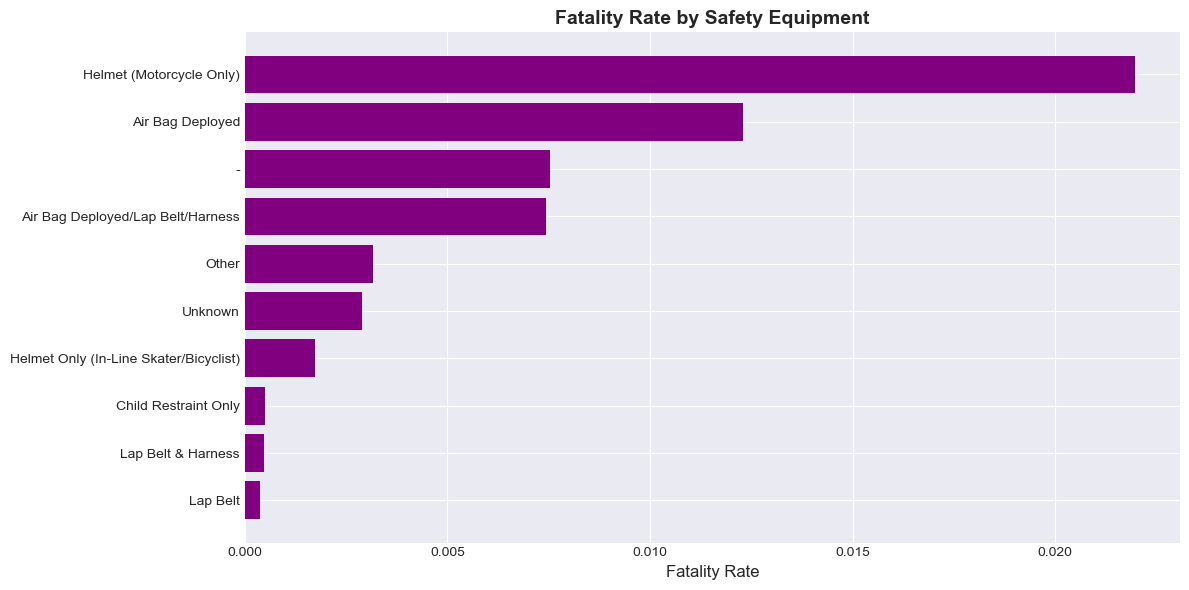

In [134]:
# Safety Equipment Analysis
print("\n--- SAFETY EQUIPMENT ANALYSIS ---")
if 'SAFETY_EQUIPMENT' in data.columns:
    print("\nTop 10 Safety Equipment Types:")
    print(data['SAFETY_EQUIPMENT'].value_counts().head(10))
    
    # Fatality rate by safety equipment
    top_safety = data['SAFETY_EQUIPMENT'].value_counts().head(10).index
    safety_df = data[data['SAFETY_EQUIPMENT'].isin(top_safety)]
    safety_fatal = safety_df.groupby('SAFETY_EQUIPMENT')['TARGET'].agg(['mean', 'count'])
    safety_fatal = safety_fatal[safety_fatal['count'] >= 10].sort_values('mean', ascending=False)
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(safety_fatal)), safety_fatal['mean'].values, color='purple')
    plt.yticks(range(len(safety_fatal)), safety_fatal.index)
    plt.xlabel('Fatality Rate', fontsize=12)
    plt.title('Fatality Rate by Safety Equipment', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


--- CONTRIBUTING FACTORS ---

Top 10 Contributing Factors:
CONTRIBUTING_FACTOR_1
Unspecified                                              17219
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion     4442
Driver Inattention/Distraction                             879
Failure to Yield Right-of-Way                              672
Alcohol Involvement                                        416
Traffic Control Disregarded                                401
Other Vehicular                                            295
View Obstructed/Limited                                    154
Cell Phone (hand-Held)                                     114
Backing Unsafely                                            91
Name: count, dtype: int64


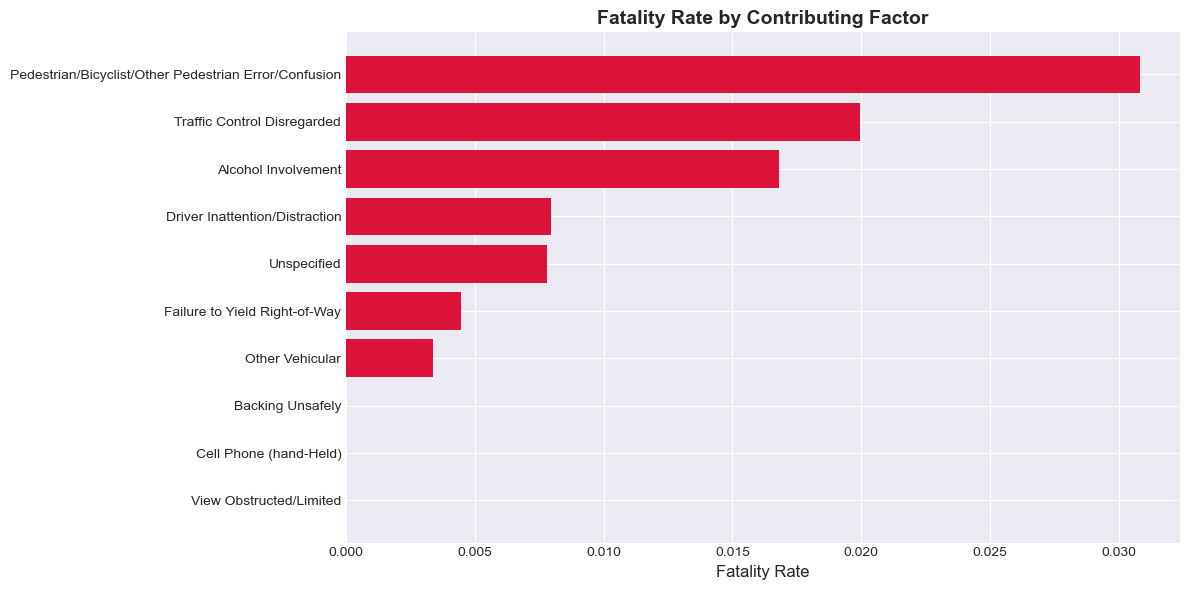

In [136]:
# Contributing Factors
print("\n--- CONTRIBUTING FACTORS ---")
if 'CONTRIBUTING_FACTOR_1' in data.columns:
    print("\nTop 10 Contributing Factors:")
    print(data['CONTRIBUTING_FACTOR_1'].value_counts().head(10))
    
    # Fatality rate by contributing factor
    top_factors = data['CONTRIBUTING_FACTOR_1'].value_counts().head(10).index
    factor_df = data[data['CONTRIBUTING_FACTOR_1'].isin(top_factors)]
    factor_fatal = factor_df.groupby('CONTRIBUTING_FACTOR_1')['TARGET'].agg(['mean', 'count'])
    factor_fatal = factor_fatal[factor_fatal['count'] >= 10].sort_values('mean', ascending=False)
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(factor_fatal)), factor_fatal['mean'].values, color='crimson')
    plt.yticks(range(len(factor_fatal)), factor_fatal.index)
    plt.xlabel('Fatality Rate', fontsize=12)
    plt.title('Fatality Rate by Contributing Factor', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

#### CORRELATION ANALYSIS

In [137]:
# Select numeric columns only
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID columns
id_cols = ['UNIQUE_ID', 'COLLISION_ID', 'PERSON_ID', 'VEHICLE_ID']
numeric_cols = [col for col in numeric_cols if col not in id_cols]

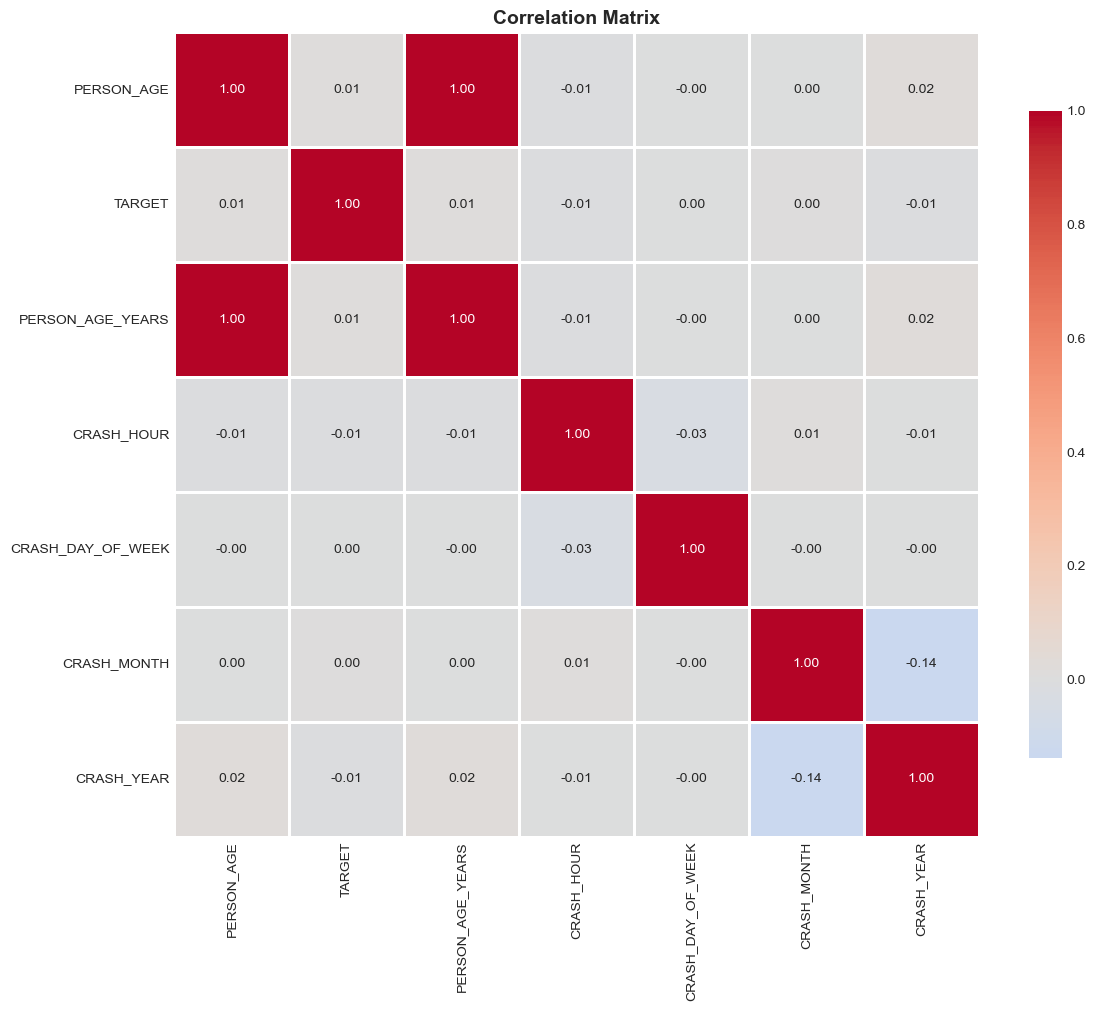


Top 15 correlations with TARGET:
TARGET               1.000000
PERSON_AGE_YEARS     0.008178
PERSON_AGE           0.008178
CRASH_MONTH          0.004241
CRASH_DAY_OF_WEEK    0.001220
CRASH_YEAR          -0.008458
CRASH_HOUR          -0.014114
Name: TARGET, dtype: float64


In [138]:
if len(numeric_cols) > 1:
    corr_matrix = data[numeric_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Correlation with target
    if 'TARGET' in corr_matrix.columns:
        target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
        print("\nTop 15 correlations with TARGET:")
        print(target_corr.head(15))

#### CRASH-LEVEL INSIGHTS

In [139]:
# Aggregate to crash level
crash_level = data.groupby('COLLISION_ID').agg({
    'TARGET': 'max',  # 1 if any fatality in crash
    'PERSON_TYPE': 'count',  # number of people involved
    'PERSON_AGE': 'mean'  # average age
}).rename(columns={'PERSON_TYPE': 'NUM_PEOPLE', 'PERSON_AGE': 'AVG_AGE'})

print(f"\nTotal unique crashes: {len(crash_level):,}")
print(f"Crashes with fatalities: {crash_level['TARGET'].sum():,}")
print(f"Crashes with only injuries: {(crash_level['TARGET'] == 0).sum():,}")

print(f"\nAverage people per crash: {crash_level['NUM_PEOPLE'].mean():.2f}")


Total unique crashes: 190,816
Crashes with fatalities: 1,003
Crashes with only injuries: 189,813

Average people per crash: 1.21


In [140]:
fatal_crashes = crash_level[crash_level['TARGET'] == 1]
injury_crashes = crash_level[crash_level['TARGET'] == 0]

print(f"\nFatal crashes:")
print(f"  Average people involved: {fatal_crashes['NUM_PEOPLE'].mean():.2f}")
print(f"  Average age: {fatal_crashes['AVG_AGE'].mean():.2f}")

print(f"\nInjury-only crashes:")
print(f"  Average people involved: {injury_crashes['NUM_PEOPLE'].mean():.2f}")
print(f"  Average age: {injury_crashes['AVG_AGE'].mean():.2f}")


Fatal crashes:
  Average people involved: 1.29
  Average age: 47.03

Injury-only crashes:
  Average people involved: 1.21
  Average age: 37.11


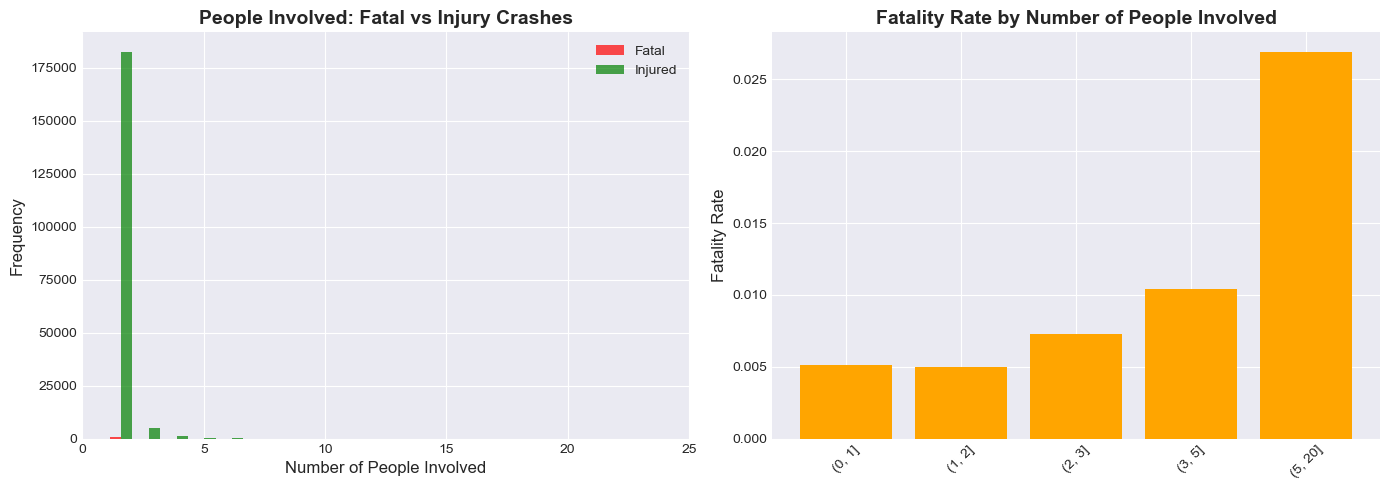

In [151]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# People involved distribution
axes[0].hist([fatal_crashes['NUM_PEOPLE'], injury_crashes['NUM_PEOPLE']], 
             bins=20, label=['Fatal', 'Injured'], alpha=0.7, color=['red', 'green'])
axes[0].set_xlabel('Number of People Involved', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('People Involved: Fatal vs Injury Crashes', fontsize=14, fontweight='bold')
axes[0].legend()

# Crash severity by number of people
people_bins = pd.cut(crash_level['NUM_PEOPLE'], bins=[0, 1, 2, 3, 5, 20])
crash_severity_by_people = crash_level.groupby(people_bins)['TARGET'].mean()
axes[1].bar(range(len(crash_severity_by_people)), crash_severity_by_people.values, color='orange')
axes[1].set_xticks(range(len(crash_severity_by_people)))
axes[1].set_xticklabels(crash_severity_by_people.index.astype(str), rotation=45)
axes[1].set_ylabel('Fatality Rate', fontsize=12)
axes[1].set_title('Fatality Rate by Number of People Involved', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## KEY INSIGHTS SUMMARY

In [152]:
print("\n" + "="*400)
print("KEY INSIGHTS FROM EDA")
print("="*40)

print("\n📊 DATASET OVERVIEW:")
print(f"   • Total records: {len(data):,}")
print(f"   • Unique crashes: {data['COLLISION_ID'].nunique():,}")
print(f"   • Date range: {data['CRASH_DATE'].min()} to {data['CRASH_DATE'].max()}")

print("\n🎯 TARGET VARIABLE:")
print(f"   • Fatal cases: {data['TARGET'].sum():,} ({data['TARGET'].mean()*100:.2f}%)")
print(f"   • Injured cases: {(data['TARGET']==0).sum():,} ({(1-data['TARGET'].mean())*100:.2f}%)")
print(f"   • Class imbalance ratio: {imbalance_ratio:.2f}:1")

print("\n⚠️ DATA QUALITY ISSUES:")
print(f"   • Missing values: {data.isnull().sum().sum():,} total")
print(f"   • Unrealistic ages (>120): {(data['PERSON_AGE'] > 120).sum()}")
print(f"   • Placeholder ages (999/9999): {((data['PERSON_AGE']==999) | (data['PERSON_AGE']==9999)).sum()}")

print("\n👥 PERSON CHARACTERISTICS:")
if 'PERSON_TYPE' in data.columns:
    most_common_type = data['PERSON_TYPE'].value_counts().index[0]
    highest_risk_type = data.groupby('PERSON_TYPE')['TARGET'].mean().sort_values(ascending=False).index[0]
    print(f"   • Most common: {most_common_type}")
    print(f"   • Highest fatality risk: {highest_risk_type}")

print("\n🚗 CRASH PATTERNS:")
if 'CRASH_HOUR' in data.columns:
    peak_hour = data['CRASH_HOUR'].mode()[0]
    most_fatal_hour = data.groupby('CRASH_HOUR')['TARGET'].mean().sort_values(ascending=False).index[0]
    print(f"   • Peak crash hour: {peak_hour}:00")
    print(f"   • Most fatal hour: {most_fatal_hour}:00")

print("\n✅ NEXT STEPS:")
print("   1. Clean age anomalies (>120, placeholders)")
print("   2. Handle missing values appropriately")
print("   3. Feature engineering based on insights")
print("   4. Address severe class imbalance (224:1)")

print("\n" + "="*40)
print("EDA COMPLETE - Ready for Notebook 2 (Feature Engineering & Modeling)")
print("="*40)


KEY INSIGHTS FROM EDA

📊 DATASET OVERVIEW:
   • Total records: 230,656
   • Unique crashes: 190,816
   • Date range: 2012-07-01 00:00:00 to 2024-01-14 00:00:00

🎯 TARGET VARIABLE:
   • Fatal cases: 1,023 (0.44%)
   • Injured cases: 229,633 (99.56%)
   • Class imbalance ratio: 224.47:1

⚠️ DATA QUALITY ISSUES:
   • Missing values: 1,796,017 total
   • Unrealistic ages (>120): 121
   • Placeholder ages (999/9999): 32

👥 PERSON CHARACTERISTICS:
   • Most common: Occupant
   • Highest fatality risk: Pedestrian

🚗 CRASH PATTERNS:
   • Peak crash hour: 17:00
   • Most fatal hour: 4:00

✅ NEXT STEPS:
   1. Clean age anomalies (>120, placeholders)
   2. Handle missing values appropriately
   3. Feature engineering based on insights
   4. Address severe class imbalance (224:1)

EDA COMPLETE - Ready for Notebook 2 (Feature Engineering & Modeling)


#### SAVE PROCESSED DATA

In [153]:
data.to_csv('eda_processed_data.csv', index=False)
print("\n✓ Processed data saved as 'eda_processed_data.csv'")


✓ Processed data saved as 'eda_processed_data.csv'
